# Injection multi-niveaux — Faible / Moyen / Fort
## Projet : Vers une évaluation fiable des workflows de data preparation générés par LLM

**Dataset :** hotel_bookings.csv
**Phase du projet :** Phase 2 — Construction des datasets bruités (niveaux de bruit)

---

### Rappel du cahier des charges

| Niveau | Description |
|---|---|
| Faible | Peu d'erreurs, formats légèrement incohérents |
| Moyen | Plusieurs colonnes touchées, valeurs manquantes et doublons |
| Fort | Erreurs multiples, formats hétérogènes, anomalies et bruit textuel |

### Comment on traduit ça en paramètres concrets

On fait varier **2 choses** entre les niveaux, pour chacune des 4 familles d'erreurs
(missing values, format, outliers, typos) :

1. **`error_rate`** (proportion de cellules corrompues par colonne) — augmente avec le niveau.
2. **le nombre de colonnes touchées** — Faible ne touche que 1-2 colonnes "symboliques" par
   famille ; Moyen et Fort touchent toutes les colonnes prévues.

Concrètement :

| Famille | Faible | Moyen | Fort |
|---|---|---|---|
| missing values | 3% — `country`, `meal` | 10% — 5 colonnes | 20% — 5 colonnes |
| format (dates) | 5% — `reservation_status_date` | 15% | 30% |
| outliers | 1% — `adr` seulement | 2% — 4 colonnes | 5% — 4 colonnes |
| typos texte | 3% — `hotel` seulement | 8% — 3 colonnes | 15% — 3 colonnes |
| typos numérique | 3% — `lead_time` seulement | 8% — 2 colonnes | 15% — 2 colonnes |

Le niveau **Moyen** correspond exactement à ce qu'on avait déjà construit précédemment
(`hotel_bookings_noisy_final.csv`) — on ne fait qu'ajouter Faible et Fort autour.

### Ce que ce notebook produit

Pour le dataset `hotel_bookings`, 3 versions bruitées distinctes + leur journal d'erreurs :
- `hotel_bookings_noisy_low.csv` + `error_log_low.csv`
- `hotel_bookings_noisy_medium.csv` + `error_log_medium.csv`
- `hotel_bookings_noisy_high.csv` + `error_log_high.csv`

Ces 3 fichiers serviront en Phase 5 à mesurer la **robustesse** d'un workflow LLM : est-ce
que sa qualité de correction se dégrade quand le niveau de bruit augmente ?

## 1. Imports et chargement du dataset clean

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path


DATA_DIR = Path("../datasets/hotel-booking-demand")
DATA_DIR.mkdir(parents=True, exist_ok=True)  # au cas où le dossier n'existe pas encore

df_clean = pd.read_csv(DATA_DIR / "clean.csv", low_memory=False)
print(f"Dimensions du dataset clean : {df_clean.shape}")
df_clean.head()

Dimensions du dataset clean : (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Les 4 fonctions d'injection

Inchangées par rapport au notebook de fusion précédent — copiées telles quelles depuis les
notebooks individuels de Yassir et Fatima-Ezzahra.

In [4]:
def inject_format_errors(df, columns=None, error_rate=0.15, random_state=42):
    '''
    Injecte des incohérences de FORMAT sur des colonnes de type date.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset propre (version de référence).
    columns : list[str] or None
        Colonnes de type date à corrompre. Par défaut : ['reservation_status_date'].
    error_rate : float
        Proportion de cellules à corrompre par colonne (0 à 1).
    random_state : int
        Graine pour la reproductibilité.

    Returns
    -------
    df_noisy : pd.DataFrame
        Copie du dataset avec les formats de date corrompus.
    error_log : pd.DataFrame
        Journal des erreurs injectées : row_index, column, original_value,
        injected_value, error_type.
    '''
    rng = np.random.default_rng(random_state)
    df_noisy = df.copy()
    columns = columns or ["reservation_status_date"]
    log_records = []

    def reformat(date_str):
        try:
            d = pd.to_datetime(date_str)
        except Exception:
            return date_str, "unparsable_original"

        variants = [
            d.strftime("%d/%m/%Y"),          # 23/12/2015
            d.strftime("%m/%d/%Y"),          # 12/23/2015 (format US, ambigu)
            d.strftime("%B %d, %Y"),         # December 23, 2015
            d.strftime("%d-%b-%Y"),          # 23-Dec-2015
            d.strftime("%Y/%m/%d"),          # 2015/12/23
            str(int(d.timestamp())),         # timestamp brut
        ]
        choice = rng.integers(0, len(variants))
        return variants[choice], "date_format_inconsistency"

    for col in columns:
        if col not in df_noisy.columns:
            continue
        n_rows = len(df_noisy)
        n_to_corrupt = int(n_rows * error_rate)
        idx_to_corrupt = rng.choice(n_rows, size=n_to_corrupt, replace=False)

        for idx in idx_to_corrupt:
            original_value = df_noisy.at[idx, col]
            new_value, err_type = reformat(original_value)
            df_noisy.at[idx, col] = new_value
            log_records.append({
                "row_index": idx,
                "column": col,
                "original_value": original_value,
                "injected_value": new_value,
                "error_type": err_type,
            })

    error_log = pd.DataFrame(log_records)
    return df_noisy, error_log


def inject_outliers(df, column_bounds=None, error_rate=0.02, random_state=42):
    '''
    Injecte des valeurs ABERRANTES sur des colonnes numériques.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset propre (version de référence).
    column_bounds : dict or None
        Dictionnaire {colonne: (min, max)} définissant la plage des valeurs aberrantes.
        Par défaut, couvre adr, lead_time, adults, babies, stays_in_week_nights,
        days_in_waiting_list.
    error_rate : float
        Proportion de cellules à corrompre par colonne (0 à 1).
    random_state : int
        Graine pour la reproductibilité.

    Returns
    -------
    df_noisy : pd.DataFrame
        Copie du dataset avec des valeurs aberrantes injectées.
    error_log : pd.DataFrame
        Journal des erreurs injectées : row_index, column, original_value,
        injected_value, error_type.
    '''
    rng = np.random.default_rng(random_state)
    df_noisy = df.copy()
    log_records = []

    default_bounds = {
    "adr": (-500, 10000),
    "babies": (10, 50),
    "stays_in_week_nights": (200, 1000),
    "days_in_waiting_list": (2000, 9000),
}
    column_bounds = column_bounds or default_bounds

    for col, (low, high) in column_bounds.items():
        if col not in df_noisy.columns:
            continue
        n_rows = len(df_noisy)
        n_to_corrupt = max(1, int(n_rows * error_rate))
        idx_to_corrupt = rng.choice(n_rows, size=n_to_corrupt, replace=False)

        for idx in idx_to_corrupt:
            original_value = df_noisy.at[idx, col]
            outlier_value = rng.uniform(low, high)
            if pd.api.types.is_integer_dtype(df[col]):
                outlier_value = int(outlier_value)
            else:
                outlier_value = round(float(outlier_value), 2)

            df_noisy.at[idx, col] = outlier_value
            log_records.append({
                "row_index": idx,
                "column": col,
                "original_value": original_value,
                "injected_value": outlier_value,
                "error_type": "outlier_value",
            })

    error_log = pd.DataFrame(log_records)
    return df_noisy, error_log

In [5]:
def inject_missing_values(df, columns=None, error_rate=0.10, random_state=42):
    '''
    Injecte des valeurs MANQUANTES (explicites ou déguisées) sur les colonnes ciblées.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset propre (version de référence).
    columns : list[str] or None
        Colonnes à corrompre. Par défaut : ['country', 'agent', 'children',
        'market_segment', 'meal'].
    error_rate : float
        Proportion de cellules à corrompre par colonne (0 à 1).
    random_state : int
        Graine pour la reproductibilité.

    Returns
    -------
    df_noisy : pd.DataFrame
        Copie du dataset avec des valeurs manquantes (réelles ou déguisées) injectées.
    error_log : pd.DataFrame
        Journal des erreurs injectées : row_index, column, original_value,
        injected_value, error_type.
    '''
    rng = np.random.default_rng(random_state)
    df_noisy = df.copy()
    columns = columns or ["country", "agent", "children", "market_segment", "meal"]
    log_records = []

    # Variantes de "manquant" : (valeur_injectee, label_pour_le_log)
    variants = [
        (np.nan, "missing_nan"),
        ("", "missing_empty_string"),
        ("NA", "missing_NA_string"),
        ("N/A", "missing_N/A_string"),
        ("unknown", "missing_unknown_string"),
        (" ", "missing_whitespace"),
    ]

    for col in columns:
        if col not in df_noisy.columns:
            continue
        # On force la colonne en type 'object' AVANT d'injecter : sinon pandas refuse
        # d'écrire une chaîne ("unknown", "NA"...) dans une colonne numérique (float64/int64).
        df_noisy[col] = df_noisy[col].astype(object)

        n_rows = len(df_noisy)
        n_to_corrupt = int(n_rows * error_rate)
        idx_to_corrupt = rng.choice(n_rows, size=n_to_corrupt, replace=False)

        for idx in idx_to_corrupt:
            original_value = df.at[idx, col]  # valeur ORIGINALE (jamais déjà bruitée)
            choice_idx = rng.integers(0, len(variants))
            new_value, err_type = variants[choice_idx]
            df_noisy.at[idx, col] = new_value
            log_records.append({
                "row_index": idx,
                "column": col,
                "original_value": original_value,
                "injected_value": new_value,
                "error_type": err_type,
            })

    error_log = pd.DataFrame(log_records)
    return df_noisy, error_log


def _typo_text(value, rng):
    '''Applique une faute de frappe aléatoire à une chaîne de caractères.'''
    s = str(value)
    if len(s) < 2:
        return s, "typo_too_short_unchanged"

    op = rng.integers(0, 5)
    i = rng.integers(0, len(s) - 1)

    if op == 0:
        # Lettre supprimée
        new_s = s[:i] + s[i + 1:]
        err_type = "typo_missing_letter"
    elif op == 1:
        # Lettre dupliquée
        new_s = s[:i] + s[i] + s[i:]
        err_type = "typo_duplicated_letter"
    elif op == 2:
        # Deux lettres adjacentes inversées
        new_s = s[:i] + s[i + 1] + s[i] + s[i + 2:]
        err_type = "typo_swapped_letters"
    elif op == 3:
        # Casse aléatoire (ex: Casablanca -> CASAblanca)
        cut = rng.integers(1, len(s))
        new_s = s[:cut].upper() + s[cut:].lower()
        err_type = "typo_random_case"
    else:
        # Espaces parasites en début/fin
        new_s = "  " + s + " "
        err_type = "typo_extra_whitespace"

    return new_s, err_type


def _typo_numeric(value, rng):
    '''Injecte un ou plusieurs caractères non numériques dans une valeur numérique.'''
    s = str(value)
    letter_pool = ["O", "l", "S", "B", "€", "kg", "j"]
    letter = letter_pool[rng.integers(0, len(letter_pool))]

    op = rng.integers(0, 3)
    if op == 0:
        # Remplace un zéro par la lettre "O" (confusion classique zero/O)
        if "0" in s:
            idx0 = s.index("0")
            new_s = s[:idx0] + "O" + s[idx0 + 1:]
        else:
            new_s = s + "O"
        err_type = "typo_zero_as_letter_O"
    elif op == 1:
        # Ajoute une unité/texte à la fin (ex: "75.0" -> "75.0kg")
        new_s = s + letter
        err_type = "typo_unit_suffix_injected"
    else:
        # Insère un caractère au milieu de la valeur
        i = rng.integers(1, max(2, len(s)))
        new_s = s[:i] + letter + s[i:]
        err_type = "typo_letter_inside_number"

    return new_s, err_type


def inject_typos(df, text_columns=None, numeric_columns=None, error_rate=0.10, random_state=42):
    '''
    Injecte des erreurs TYPOGRAPHIQUES : fautes de frappe sur colonnes textuelles,
    et caractères non numériques insérés dans des colonnes numériques.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset propre (version de référence).
    text_columns : list[str] or None
        Colonnes textuelles/catégorielles à corrompre.
        Par défaut : ['hotel', 'country', 'meal', 'deposit_type', 'customer_type'].
    numeric_columns : list[str] or None
        Colonnes numériques dans lesquelles injecter des caractères.
        Par défaut : ['adr', 'lead_time', 'adults'].
    error_rate : float
        Proportion de cellules à corrompre par colonne (0 à 1).
    random_state : int
        Graine pour la reproductibilité.

    Returns
    -------
    df_noisy : pd.DataFrame
        Copie du dataset avec des erreurs typographiques injectées.
        NB : après injection, les colonnes numériques touchées deviennent de type `object`
        (mélange de nombres et de texte), ce qui est volontaire et reproduit un cas réel.
    error_log : pd.DataFrame
        Journal des erreurs injectées : row_index, column, original_value,
        injected_value, error_type.
    '''
    rng = np.random.default_rng(random_state)
    df_noisy = df.copy()
    text_columns = text_columns or ["hotel", "deposit_type", "customer_type"]
    numeric_columns = numeric_columns or ["lead_time", "adults"]
    log_records = []

    def apply_corruption(columns, corrupt_fn):
        for col in columns:
            if col not in df_noisy.columns:
                continue
            # S'assurer que la colonne peut recevoir du texte
            df_noisy[col] = df_noisy[col].astype(object)

            n_rows = len(df_noisy)
            n_to_corrupt = int(n_rows * error_rate)
            idx_to_corrupt = rng.choice(n_rows, size=n_to_corrupt, replace=False)

            for idx in idx_to_corrupt:
                original_value = df.at[idx, col]  # valeur ORIGINALE (pas déjà bruitée)
                if pd.isna(original_value):
                    continue
                new_value, err_type = corrupt_fn(original_value, rng)
                df_noisy.at[idx, col] = new_value
                log_records.append({
                    "row_index": idx,
                    "column": col,
                    "original_value": original_value,
                    "injected_value": new_value,
                    "error_type": err_type,
                })

    apply_corruption(text_columns, _typo_text)
    apply_corruption(numeric_columns, _typo_numeric)

    error_log = pd.DataFrame(log_records)
    return df_noisy, error_log


DISGUISED_MISSING = {"", "na", "n/a", "unknown", " ", "nan", "none", "null"}

def profile_dataset(df, top_n=5):
    '''
    Construit un profil statistique du dataset, utilisable dans un prompt LLM (approche
    "prompt avec profilage").

    Returns
    -------
    profile : pd.DataFrame
        Une ligne par colonne avec : dtype détecté, % manquants (réels + déguisés),
        statistiques descriptives (numérique) ou valeurs les plus fréquentes (catégorielle).
    '''
    records = []
    n_rows = len(df)

    for col in df.columns:
        series = df[col]
        is_numeric = pd.api.types.is_numeric_dtype(series)

        # Manquants réels
        n_na_real = series.isna().sum()

        # Manquants déguisés (seulement pertinent pour les colonnes non numériques)
        if not is_numeric:
            n_na_disguised = series.astype(str).str.strip().str.lower().isin(DISGUISED_MISSING).sum()
        else:
            n_na_disguised = 0

        pct_missing = round(100 * (n_na_real + n_na_disguised) / n_rows, 2)

        record = {
            "column": col,
            "dtype_detected": "numeric" if is_numeric else "categorical/text",
            "pct_missing": pct_missing,
            "n_unique": series.nunique(dropna=True),
        }

        if is_numeric:
            record["min"] = series.min()
            record["max"] = series.max()
            record["mean"] = round(series.mean(), 2)
            record["std"] = round(series.std(), 2)
        else:
            top_values = series.value_counts().head(top_n).to_dict()
            record["top_values"] = top_values

        records.append(record)

    return pd.DataFrame(records)


## 3. Configuration des 3 niveaux de bruit

C'est ici que se joue toute la différence entre Faible / Moyen / Fort : un seul dictionnaire
de configuration, que `inject_all()` va lire pour savoir quel `error_rate` et quelles colonnes
utiliser à chaque niveau.

In [6]:
NOISE_LEVELS = {
    "low": {
        "missing":       {"rate": 0.03, "columns": ["country", "meal"]},
        "format":        {"rate": 0.05, "columns": ["reservation_status_date"]},
        "outliers":      {"rate": 0.01, "columns": ["adr"]},
        "typos_text":    {"rate": 0.03, "columns": ["hotel"]},
        "typos_numeric": {"rate": 0.03, "columns": ["lead_time"]},
    },
    "medium": {
        "missing":       {"rate": 0.10, "columns": ["country", "agent", "children",
                                                      "market_segment", "meal"]},
        "format":        {"rate": 0.15, "columns": ["reservation_status_date"]},
        "outliers":      {"rate": 0.02, "columns": ["adr", "babies",
                                                      "stays_in_week_nights",
                                                      "days_in_waiting_list"]},
        "typos_text":    {"rate": 0.08, "columns": ["hotel", "deposit_type",
                                                      "customer_type"]},
        "typos_numeric": {"rate": 0.08, "columns": ["lead_time", "adults"]},
    },
    "high": {
        "missing":       {"rate": 0.20, "columns": ["country", "agent", "children",
                                                      "market_segment", "meal"]},
        "format":        {"rate": 0.30, "columns": ["reservation_status_date"]},
        "outliers":      {"rate": 0.05, "columns": ["adr", "babies",
                                                      "stays_in_week_nights",
                                                      "days_in_waiting_list"]},
        "typos_text":    {"rate": 0.15, "columns": ["hotel", "deposit_type",
                                                      "customer_type"]},
        "typos_numeric": {"rate": 0.15, "columns": ["lead_time", "adults"]},
    },
}

# Bornes réalistes pour les outliers (identiques aux 3 niveaux ; seul le taux/les
# colonnes changent, pas la définition de ce qu'est une valeur aberrante)
OUTLIER_BOUNDS = {
    "adr": (-500, 10000),
    "babies": (10, 50),
    "stays_in_week_nights": (200, 1000),
    "days_in_waiting_list": (2000, 9000),
}

## 4. `inject_all()` — version paramétrée par niveau

Même principe que la version précédente (on part toujours de `df_clean`, colonnes disjointes
entre familles), mais les paramètres viennent maintenant de `NOISE_LEVELS[level]` au lieu
d'être fixés en dur.

In [7]:
def inject_all(df_clean, level="medium", random_state=42):
    '''
    Applique les 4 types d'erreurs sur une seule copie du dataset clean, avec l'intensité
    correspondant au niveau de bruit choisi ("low", "medium", "high").

    Parameters
    ----------
    df_clean : pd.DataFrame
        Dataset propre de référence (jamais modifié directement).
    level : str
        "low", "medium" ou "high" — cf. NOISE_LEVELS.
    random_state : int
        Graine commune de reproductibilité.

    Returns
    -------
    df_final : pd.DataFrame
        Dataset avec les 4 types d'erreurs appliqués, à l'intensité du niveau choisi.
    full_log : pd.DataFrame
        Concaténation des 4 error_log, avec les colonnes 'error_family' et 'noise_level'.
    '''
    if level not in NOISE_LEVELS:
        raise ValueError(f"level doit être 'low', 'medium' ou 'high', reçu : {level}")
    cfg = NOISE_LEVELS[level]

    df_current = df_clean.copy()
    all_logs = []

    # --- Étape 1 : valeurs manquantes ---
    df_current, log_missing = inject_missing_values(
        df_current, columns=cfg["missing"]["columns"],
        error_rate=cfg["missing"]["rate"], random_state=random_state)
    log_missing["error_family"] = "missing_values"
    all_logs.append(log_missing)

    # --- Étape 2 : erreurs de format ---
    df_current, log_format = inject_format_errors(
        df_current, columns=cfg["format"]["columns"],
        error_rate=cfg["format"]["rate"], random_state=random_state)
    log_format["error_family"] = "format_errors"
    all_logs.append(log_format)

    # --- Étape 3 : valeurs aberrantes ---
    bounds = {c: OUTLIER_BOUNDS[c] for c in cfg["outliers"]["columns"]}
    df_current, log_outliers = inject_outliers(
        df_current, column_bounds=bounds,
        error_rate=cfg["outliers"]["rate"], random_state=random_state)
    log_outliers["error_family"] = "outliers"
    all_logs.append(log_outliers)

    # --- Étape 4 : typos ---
    df_current, log_typos = inject_typos(
        df_current,
        text_columns=cfg["typos_text"]["columns"],
        numeric_columns=cfg["typos_numeric"]["columns"],
        error_rate=cfg["typos_text"]["rate"], random_state=random_state)
    log_typos["error_family"] = "typos"
    all_logs.append(log_typos)

    full_log = pd.concat(all_logs, ignore_index=True)
    full_log["noise_level"] = level
    return df_current, full_log

## 5. Génération des 3 versions bruitées

In [8]:
results = {}
for level in ["low", "medium", "high"]:
    df_noisy, log = inject_all(df_clean, level=level, random_state=42)
    results[level] = {"df": df_noisy, "log": log}
    print(f"[{level.upper():6}] {len(log):6} erreurs injectées | "
          f"shape={df_noisy.shape} | familles={log['error_family'].nunique()}")

[LOW   ]  21486 erreurs injectées | shape=(119390, 32) | familles=4
[MEDIUM] 134906 erreurs injectées | shape=(119390, 32) | familles=4
[HIGH  ] 268623 erreurs injectées | shape=(119390, 32) | familles=4


## 6. Vérification — le bruit augmente bien de low à high

In [9]:
summary_rows = []
for level in ["low", "medium", "high"]:
    log = results[level]["log"]
    row = {"level": level, "total_errors": len(log)}
    for family in log["error_family"].unique():
        row[family] = (log["error_family"] == family).sum()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("level")
summary_df

,total_errors,missing_values,format_errors,outliers,typos
level,,,,,
low,21486,7162,5969,1193,7162
medium,134906,59695,17908,9548,47755
high,268623,119390,35817,23876,89540


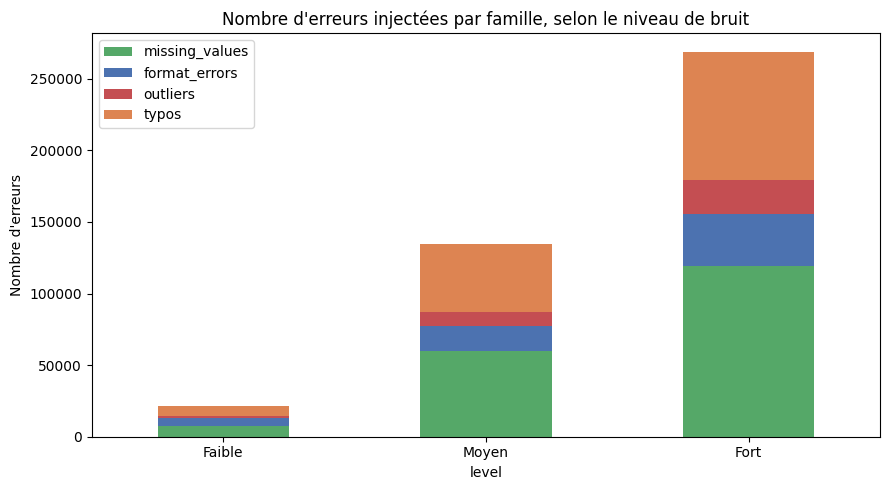

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
summary_df.drop(columns="total_errors").plot(kind="bar", stacked=True, ax=ax,
    color=["#55A868", "#4C72B0", "#C44E52", "#DD8452"])
ax.set_title("Nombre d'erreurs injectées par famille, selon le niveau de bruit")
ax.set_ylabel("Nombre d'erreurs")
ax.set_xticklabels(["Faible", "Moyen", "Fort"], rotation=0)
plt.tight_layout()
plt.show()

## 7. Sauvegarde des livrables

Sauvegarde directement dans `benchmark/datasets/hotel_bookings/` (le dossier que tu as déjà
créé), à côté de `clean.csv` :
`noisy_low.csv`, `noisy_medium.csv`, `noisy_high.csv`, `error_log_low.csv`,
`error_log_medium.csv`, `error_log_high.csv`, `metadata.json`.

In [11]:
metadata = {"dataset": "hotel_bookings", "n_rows": int(df_clean.shape[0]),
            "n_cols": int(df_clean.shape[1]), "levels": {}}

for level in ["low", "medium", "high"]:
    df_noisy = results[level]["df"]
    log = results[level]["log"]

    df_noisy.to_csv(DATA_DIR / f"noisy_{level}.csv", index=False)
    log.to_csv(DATA_DIR / f"error_log_{level}.csv", index=False)

    metadata["levels"][level] = {
        "total_errors": int(len(log)),
        "error_rate_global": round(len(log) / (df_clean.shape[0] * df_clean.shape[1]), 4),
        "errors_by_family": log["error_family"].value_counts().to_dict(),
        "config": NOISE_LEVELS[level],
    }

with open(DATA_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str, ensure_ascii=False)

print(f"Fichiers sauvegardés dans {DATA_DIR}/ :")
for level in ["low", "medium", "high"]:
    print(f"  - noisy_{level}.csv")
    print(f"  - error_log_{level}.csv")
print("  - metadata.json")

Fichiers sauvegardés dans ..\datasets\hotel-booking-demand/ :
  - noisy_low.csv
  - error_log_low.csv
  - noisy_medium.csv
  - error_log_medium.csv
  - noisy_high.csv
  - error_log_high.csv
  - metadata.json
